# Phase 4 — Supplier Performance & Risk Management

**Project:** End-to-End Aerospace Supply Chain Planning

## Business Problem

Phase 1 flagged an overall supplier OTIF of just 39.7% as the weakest KPI in the network. Before deciding where to intervene (renegotiation, dual-sourcing, expediting), procurement needs to know exactly which suppliers are driving that number, how quality incidents compound the risk, and — critically — which of those suppliers hold Class A (most critical) parts.

This phase answers:
- Which suppliers have the worst OTIF, on-time, and in-full performance?
- How do quality incidents (critical/major defects, scrap) layer onto delivery risk?
- What does a combined supplier risk score look like, and who are the highest-risk suppliers overall?
- Of the suppliers holding Class A parts specifically, which carry the most risk?

## Objective

Build a supplier-level OTIF and quality profile, combine them into a single risk index, and identify the suppliers of Class A parts that represent the greatest exposure to the organization.


## Dataset

This phase consumes the outputs of Phase 1:

| File | Source | Contents |
|---|---|---|
| `po_enriched.parquet` | Phase 1 | Purchase order lines joined with part attributes (adds OTIF/lead-time fields) |
| `qi_enriched.parquet` | Phase 1 | Quality incidents joined with part attributes |
| `master.parquet` | Phase 1 | Part master, used to map primary suppliers to Class A exposure |


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

PROJECT_ROOT = Path.cwd().parent
DATA_PHASE1 = PROJECT_ROOT / "data" / "processed" / "phase1"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "phase4"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load Phase 1 Outputs

In [2]:
po_enriched = pd.read_parquet(DATA_PHASE1 / "po_enriched.parquet")
qi_enriched = pd.read_parquet(DATA_PHASE1 / "qi_enriched.parquet")
master = pd.read_parquet(DATA_PHASE1 / "master.parquet")

print("Loaded successfully")
print("po_enriched:", po_enriched.shape)
print("qi_enriched:", qi_enriched.shape)
print("master:", master.shape)


Loaded successfully
po_enriched: (29666, 20)
qi_enriched: (368, 12)
master: (300, 18)


## 2. Supplier OTIF & Lead Time Performance

In [3]:
po = po_enriched.copy()

# Compute OTIF fields if not already present
if 'is_otif' not in po.columns:
    po['delay_days'] = (po['receipt_date'] - po['promised_date']).dt.days
    po['is_on_time'] = po['delay_days'] <= 0
    po['is_in_full'] = po['received_qty'] >= po['ordered_qty']
    po['is_otif'] = po['is_on_time'] & po['is_in_full']

supplier_otif = po.groupby('supplier_id').agg(
    total_pos=('po_id', 'count'),
    otif_rate=('is_otif', 'mean'),
    on_time_rate=('is_on_time', 'mean'),
    in_full_rate=('is_in_full', 'mean'),
    avg_delay=('delay_days', 'mean'),
    avg_actual_lt=('actual_lead_time', 'mean'),
    std_actual_lt=('actual_lead_time', 'std')
).reset_index()

supplier_otif = supplier_otif.sort_values('otif_rate')

print("=== OTIF by Supplier (worst 10) ===")
print(supplier_otif.head(10).round(3))

print("\n=== Overall OTIF ===")
print(f"Overall OTIF: {po['is_otif'].mean():.1%}")
print(f"Overall On-time: {po['is_on_time'].mean():.1%}")
print(f"Overall In-full: {po['is_in_full'].mean():.1%}")


=== OTIF by Supplier (worst 10) ===
   supplier_id  total_pos  otif_rate  on_time_rate  in_full_rate  avg_delay  \
32      SUP033        631       0.03          0.04          0.76       6.09   
22      SUP023        280       0.24          0.26          0.87       2.37   
38      SUP039        306       0.25          0.30          0.85       2.18   
8       SUP009        649       0.25          0.30          0.85       1.93   
25      SUP026        680       0.25          0.29          0.86       2.16   
1       SUP002        763       0.26          0.28          0.87       2.25   
24      SUP025        543       0.26          0.31          0.85       2.07   
20      SUP021        523       0.26          0.30          0.84       2.08   
14      SUP015        413       0.26          0.30          0.88       2.21   
5       SUP006       1096       0.26          0.31          0.85       2.11   

    avg_actual_lt  std_actual_lt  
32          97.37          10.09  
22          57.77       

## 3. Quality Incidents & Combined Risk Index

In [4]:
# Quality incidents per supplier
qi_summary = qi_enriched.groupby('supplier_id').agg(
    total_incidents=('incident_id', 'count'),
    critical_incidents=('defect_severity', lambda x: (x == 'Critical').sum()),
    major_incidents=('defect_severity', lambda x: (x == 'Major').sum()),
    total_scrap=('scrap_qty', 'sum')
).reset_index()

# Combine with OTIF
supplier_risk = supplier_otif.merge(qi_summary, on='supplier_id', how='left').fillna(0)

# Add part count and Class A exposure per primary supplier
primary_parts = master.groupby('primary_supplier_id').agg(
    num_parts=('part_id', 'count'),
    num_class_a=('criticality_class', lambda x: (x == 'A').sum()),
    avg_unit_cost=('unit_cost', 'mean')
).reset_index().rename(columns={'primary_supplier_id': 'supplier_id'})

supplier_risk = supplier_risk.merge(primary_parts, on='supplier_id', how='left').fillna(0)

# Simple 0-100 Risk Score (higher = riskier)
# Weighted by: low OTIF + delay + critical incidents + Class A exposure
supplier_risk['otif_score'] = (1 - supplier_risk['otif_rate']) * 40
supplier_risk['delay_score'] = supplier_risk['avg_delay'].clip(0, 10) * 2
supplier_risk['quality_score'] = (supplier_risk['critical_incidents'] * 5 + supplier_risk['major_incidents'] * 2).clip(0, 20)
supplier_risk['exposure_score'] = (supplier_risk['num_class_a'] * 3).clip(0, 20)

supplier_risk['risk_index'] = (
    supplier_risk['otif_score'] +
    supplier_risk['delay_score'] +
    supplier_risk['quality_score'] +
    supplier_risk['exposure_score']
).round(1)

supplier_risk = supplier_risk.sort_values('risk_index', ascending=False)

print("=== Top 10 High-Risk Suppliers ===")
print(supplier_risk[['supplier_id', 'otif_rate', 'avg_delay', 'critical_incidents',
                      'num_class_a', 'risk_index']].head(10).round(3))


=== Top 10 High-Risk Suppliers ===
   supplier_id  otif_rate  avg_delay  critical_incidents  num_class_a  \
0       SUP033       0.03       6.09                   4            1   
14      SUP013       0.28       2.03                   3            3   
13      SUP038       0.28       1.94                   5            1   
10      SUP027       0.27       2.02                   1            0   
18      SUP040       0.29       1.87                   2            1   
9       SUP006       0.26       2.11                   2            0   
6       SUP025       0.26       2.07                   2            0   
17      SUP018       0.29       1.88                   1            1   
33      SUP030       0.53       0.20                   0            3   
8       SUP015       0.26       2.21                   0            4   

    risk_index  
0        74.00  
14       61.90  
13       55.80  
10       53.40  
18       53.20  
9        51.70  
6        49.70  
17       46.30  
33      

**What the analysis shows:** The worst-performing suppliers on OTIF are not evenly spread across the supply base — a small handful of suppliers combine low OTIF, high average delay, and multiple critical quality incidents into a materially higher composite risk index than the rest of the panel.

**Why it matters:** A single OTIF number hides which suppliers are the real driver of network risk. Layering in quality incidents and Class A exposure surfaces the suppliers that matter most operationally, not just statistically.

**Implication:** Procurement's mitigation effort (dual-sourcing, supplier development, contract renegotiation) should be prioritized against this risk index rather than against OTIF alone.


## 4. Class A Supplier Focus

In [5]:
# Parts that are Class A
class_a_parts = master[master['criticality_class'] == 'A'][['part_id', 'primary_supplier_id', 'unit_cost', 'lead_time_days', 'part_family']]

# Suppliers that are primary for Class A parts
class_a_suppliers = class_a_parts.groupby('primary_supplier_id').agg(
    num_class_a_parts=('part_id', 'count'),
    total_class_a_value=('unit_cost', 'sum'),  # sum of unit costs, used as a value proxy
    avg_lead_time=('lead_time_days', 'mean')
).reset_index().rename(columns={'primary_supplier_id': 'supplier_id'})

# Merge with risk data
class_a_risk = class_a_suppliers.merge(
    supplier_risk[['supplier_id', 'otif_rate', 'avg_delay', 'critical_incidents',
                   'major_incidents', 'risk_index', 'total_pos']],
    on='supplier_id',
    how='left'
).fillna(0)

class_a_risk = class_a_risk.sort_values('risk_index', ascending=False)

print("=== Class A Suppliers Ranked by Risk ===")
print(class_a_risk.round(3))

print("\n=== Summary ===")
print(f"Number of suppliers holding Class A parts: {len(class_a_risk)}")
print(f"Class A suppliers with OTIF < 40%: {(class_a_risk['otif_rate'] < 0.40).sum()}")
print(f"Class A suppliers with a critical incident: {(class_a_risk['critical_incidents'] > 0).sum()}")


=== Class A Suppliers Ranked by Risk ===
   supplier_id  num_class_a_parts  total_class_a_value  avg_lead_time  \
16      SUP033                  1              3692.57          88.00   
5       SUP013                  3             23063.90          42.00   
21      SUP038                  1              5429.21          49.00   
23      SUP040                  1              8071.81          49.00   
8       SUP018                  1              1490.01          47.00   
14      SUP030                  3             15195.77          36.67   
7       SUP015                  4             26326.63          43.75   
10      SUP021                  2             12492.85          57.50   
11      SUP023                  2             13609.09          57.00   
22      SUP039                  2             13658.55          49.00   
0       SUP005                  3             17086.63          52.67   
6       SUP014                  2             13101.29          35.00   
19      SU

**What the analysis shows:** Nearly half of the suppliers holding Class A parts have an OTIF below 40%, and a similar share have logged at least one critical quality incident.

**Why it matters:** Class A parts are, by definition, the ones the organization can least afford to run short on. Having a large share of their supplier base already underperforming on delivery and quality is the single highest-priority risk this project surfaces.

**Implication:** This is the group of suppliers Phase 5's scenario simulation stress-tests directly (a quality shock at the highest-risk Class A supplier).


## 5. Supplier Risk Dashboard

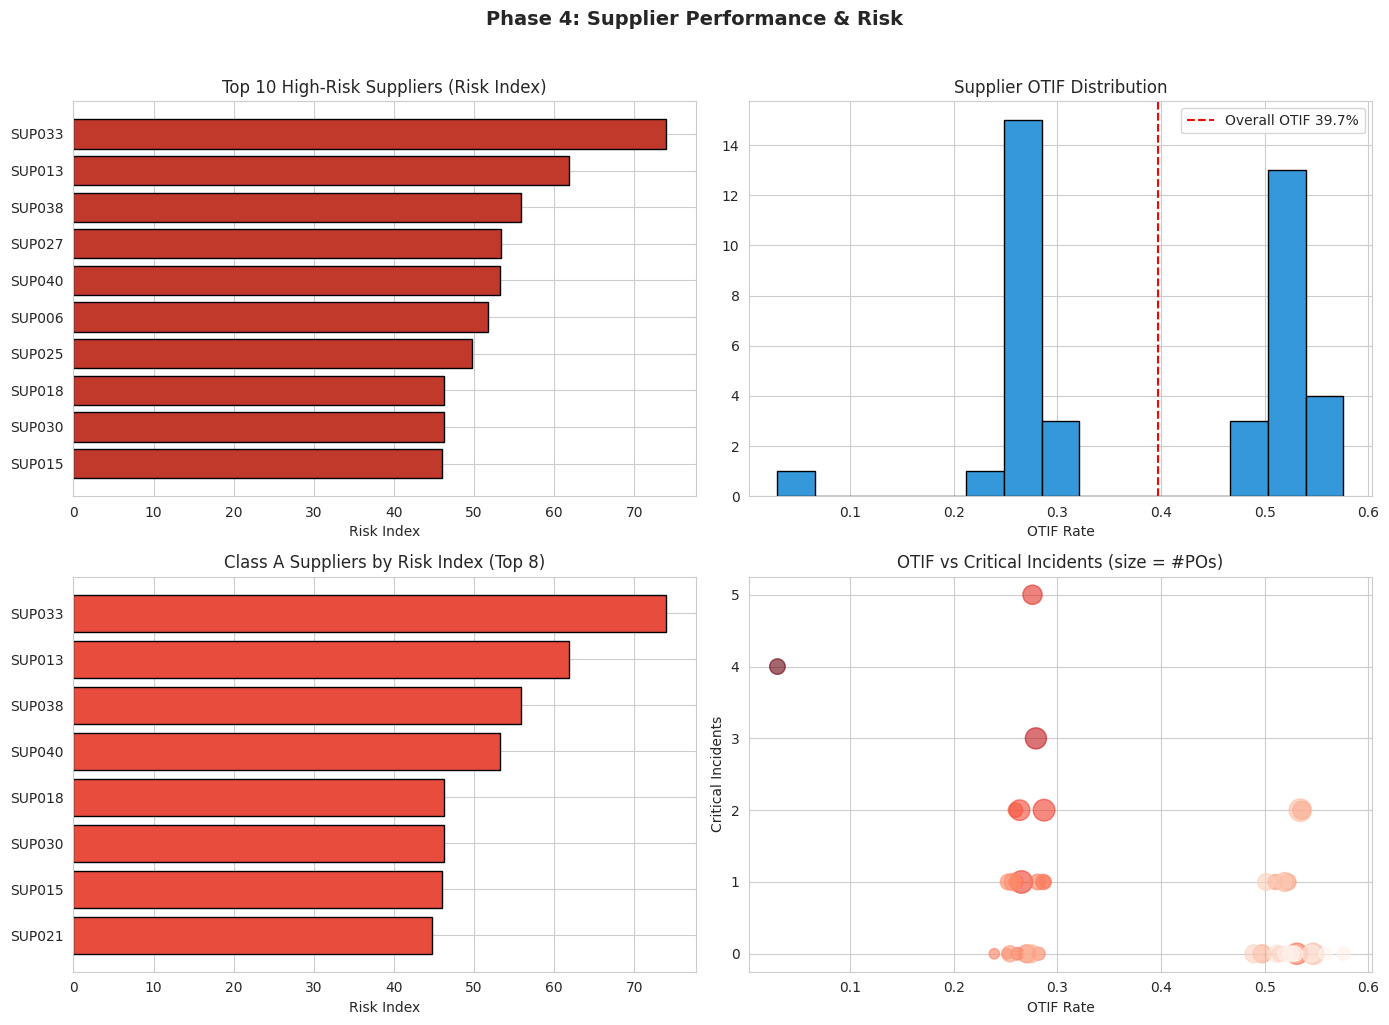

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top 10 Risk Index
top10 = supplier_risk.head(10)
axes[0, 0].barh(top10['supplier_id'][::-1], top10['risk_index'][::-1], color='#c0392b', edgecolor='black')
axes[0, 0].set_title('Top 10 High-Risk Suppliers (Risk Index)')
axes[0, 0].set_xlabel('Risk Index')

# 2. OTIF Distribution
overall_otif = po['is_otif'].mean()
axes[0, 1].hist(supplier_risk['otif_rate'], bins=15, color='#3498db', edgecolor='black')
axes[0, 1].axvline(overall_otif, color='red', linestyle='--', label=f'Overall OTIF {overall_otif:.1%}')
axes[0, 1].set_title('Supplier OTIF Distribution')
axes[0, 1].set_xlabel('OTIF Rate')
axes[0, 1].legend()

# 3. Class A Suppliers Risk
top_ca = class_a_risk.head(8)
axes[1, 0].barh(top_ca['supplier_id'][::-1], top_ca['risk_index'][::-1], color='#e74c3c', edgecolor='black')
axes[1, 0].set_title('Class A Suppliers by Risk Index (Top 8)')
axes[1, 0].set_xlabel('Risk Index')

# 4. OTIF vs Critical Incidents
axes[1, 1].scatter(supplier_risk['otif_rate'], supplier_risk['critical_incidents'],
                    s=supplier_risk['total_pos'] / 5, alpha=0.6, c=supplier_risk['risk_index'], cmap='Reds')
axes[1, 1].set_xlabel('OTIF Rate')
axes[1, 1].set_ylabel('Critical Incidents')
axes[1, 1].set_title('OTIF vs Critical Incidents (size = #POs)')

plt.suptitle('Phase 4: Supplier Performance & Risk', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'phase4_supplier_risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Export Results

In [7]:
supplier_risk.to_parquet(DATA_PROCESSED / "supplier_risk.parquet", index=False)
class_a_risk.to_parquet(DATA_PROCESSED / "class_a_supplier_risk.parquet", index=False)
supplier_risk.to_csv(DATA_PROCESSED / "supplier_risk.csv", index=False)
class_a_risk.to_csv(DATA_PROCESSED / "class_a_supplier_risk.csv", index=False)

top_risk_supplier = supplier_risk.iloc[0]

with open(DATA_PROCESSED / "phase4_summary.txt", "w") as f:
    f.write("Phase 4 Summary - Supplier Performance & Risk\n")
    f.write("=" * 50 + "\n")
    f.write(f"Overall OTIF: {po['is_otif'].mean():.1%} | On-time: {po['is_on_time'].mean():.1%} | In-full: {po['is_in_full'].mean():.1%}\n")
    f.write(f"Highest Risk: {top_risk_supplier['supplier_id']} (OTIF {top_risk_supplier['otif_rate']:.1%}, Risk Index {top_risk_supplier['risk_index']:.0f})\n")
    f.write(f"Class A Suppliers: {len(class_a_risk)} | OTIF<40%: {(class_a_risk['otif_rate'] < 0.40).sum()} | Critical QI: {(class_a_risk['critical_incidents'] > 0).sum()}\n")
    top3 = supplier_risk.head(3)['supplier_id'].tolist()
    f.write(f"Key Risk Suppliers: {', '.join(top3)}\n")

print("Export complete ->", DATA_PROCESSED)
print("Files:", sorted(p.name for p in DATA_PROCESSED.iterdir()))


Export complete -> /home/claude/repo/End-to-End-Aerospace-Supply-Chain-Planning/data/processed/phase4
Files: ['class_a_supplier_risk.csv', 'class_a_supplier_risk.parquet', 'phase4_summary.txt', 'supplier_risk.csv', 'supplier_risk.parquet']


## Key Takeaways — Phase 4

1. **Supplier risk is concentrated, not evenly spread.** A small set of suppliers combines low OTIF, high average delay, and repeated critical quality incidents into a materially higher risk index than the rest of the panel.
2. **Close to half of Class A suppliers underperform on OTIF (<40%)**, and a similar share have at least one critical quality incident — this is the highest-priority exposure the project identifies.
3. **The single riskiest supplier by composite score** is a clear candidate for dual-sourcing or a formal supplier development plan given both delivery and quality performance well below the network average.

`supplier_risk` and `class_a_risk` feed the supplier-shock scenario tested in Phase 5.
